In [3]:
# Run this cell at the beginning of each session to set up the environment
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/cs372_final_project')

# First time: clone repo
# !git clone https://github.com/victoriaf55/cs372-final.git

# Every subsequent session: pull latest
!git -C cs372-final pull

# Install dependencies
!apt-get install -y xvfb ffmpeg > /dev/null 2>&1
!pip install gymnasium[mujoco] torch tensorboard pyvirtualdisplay > /dev/null 2>&1

# Verify installation
import gymnasium as gym

env = gym.make("InvertedPendulum-v5")
obs, info = env.reset()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
env.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Observation space: Box(-inf, inf, (4,), float64)
Action space: Box(-3.0, 3.0, (1,), float32)


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd

def load_tensorboard_logs(log_dir):
    # AI-GENERATED: TensorBoard log extraction generated by Claude
    ea = EventAccumulator(log_dir)
    ea.Reload()
    
    print("Available tags:", ea.Tags()['scalars'])
    
    # Extract reward data
    reward_events = ea.Scalars("reward/mean_reward")
    policy_loss_events = ea.Scalars("losses/policy_loss")
    value_loss_events = ea.Scalars("losses/value_loss")
    entropy_events = ea.Scalars("losses/entropy")
    
    reward_df = pd.DataFrame([
        {"timestep": e.step, "mean_reward": e.value} 
        for e in reward_events
    ])
    losses_df = pd.DataFrame([
        {
            "timestep": p.step,
            "policy_loss": p.value,
            "value_loss": v.value,
            "entropy": en.value
        }
        for p, v, en in zip(policy_loss_events, value_loss_events, entropy_events)
    ])
    
    return reward_df, losses_df

LOG_DIR = "/content/drive/MyDrive/cs372_final_project/logs/STND_ppo_lr0.0003_clip0.2_valcoeff0.5_04252026_024313"
reward_df, losses_df = load_tensorboard_logs(LOG_DIR)

Available tags: ['reward/mean_reward', 'losses/policy_loss', 'losses/value_loss', 'losses/entropy']


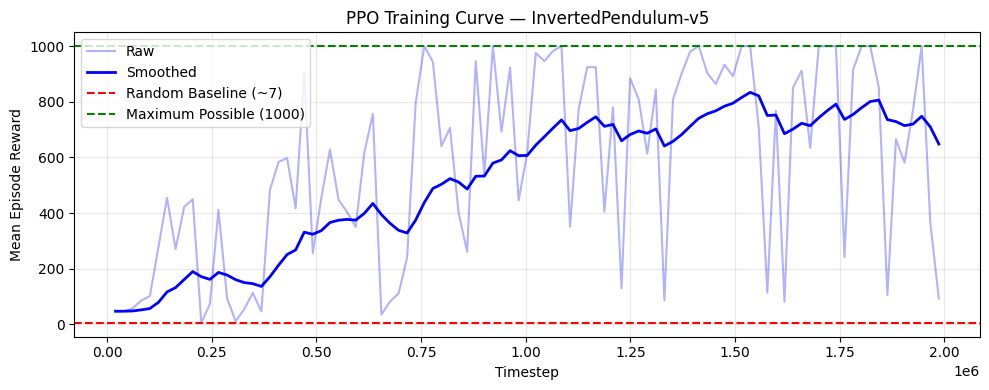

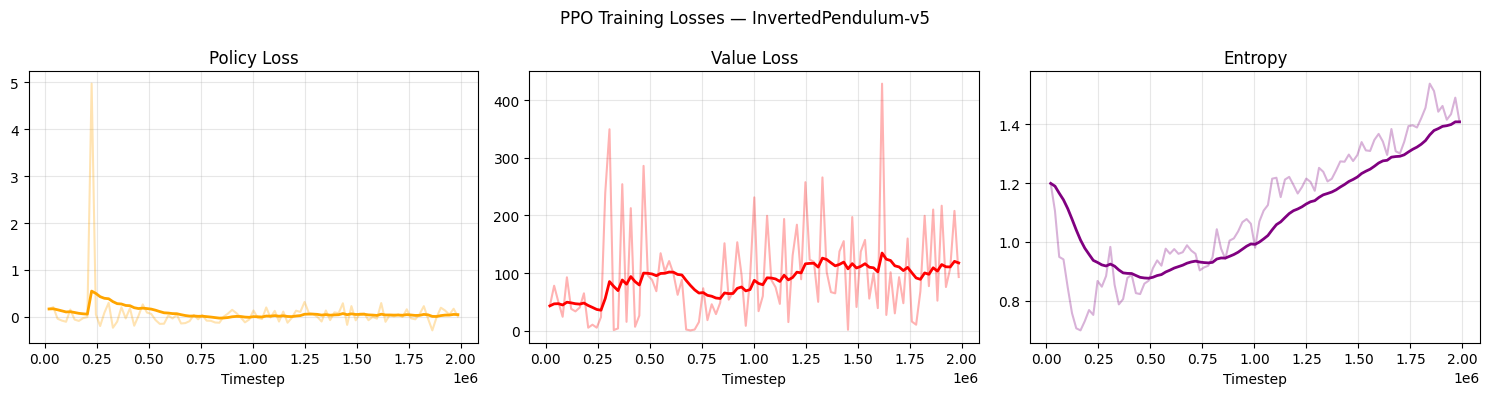

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

def smooth(values, weight=0.9):
    # AI-GENERATED: Exponential moving average smoothing generated by Claude
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

# --- Plot 1: Training Reward Curve ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(reward_df["timestep"], reward_df["mean_reward"], 
        alpha=0.3, color="blue", label="Raw")
ax.plot(reward_df["timestep"], smooth(reward_df["mean_reward"].tolist()),
        color="blue", linewidth=2, label="Smoothed")
ax.axhline(y=4, color="red", linestyle="--", linewidth=1.5, label="Random Baseline (~7)")
ax.axhline(y=1000, color="green", linestyle="--", linewidth=1.5, label="Maximum Possible (1000)")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean Episode Reward")
ax.set_title("PPO Training Curve — InvertedPendulum-v5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/training_curve.png", dpi=150)
plt.show()

# --- Plot 2: Loss Curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in zip(
    axes,
    ["policy_loss", "value_loss", "entropy"],
    ["Policy Loss", "Value Loss", "Entropy"],
    ["orange", "red", "purple"]
):
    ax.plot(losses_df["timestep"], losses_df[col],
            alpha=0.3, color=color)
    ax.plot(losses_df["timestep"], smooth(losses_df[col].tolist()),
            color=color, linewidth=2)
    ax.set_xlabel("Timestep")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("PPO Training Losses — InvertedPendulum-v5")
plt.tight_layout()
plt.savefig("plots/loss_curves.png", dpi=150)
plt.show()